In [1]:
import pickle
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sympy import sympify, latex
from sympy import symbols, Float
from copy import copy, deepcopy
import pynumdiff
from scipy.optimize import curve_fit
from matplotlib.lines import Line2D

# Import Machine Scientist
from importlib.machinery import SourceFileLoader
import sys
# Get the absolute path of the script's directory
script_dir = os.getcwd()
# Define the relative path to the module
relative_module_path = "../I-BMS-2d/parallel_ode.py"
path = os.path.join(script_dir, relative_module_path)
ms = SourceFileLoader("ms", path).load_module()

#Import prior
path = os.path.join(script_dir, "../I-BMS-2d/Prior/")
sys.path.append(path)
from fit_prior import read_prior_par
prior = read_prior_par('../I-BMS-2d/Prior/final_prior_param_sq.named_equations.nv2.np8.2016-09-09 18:49:42.800618.dat')

# Import Machine Scientist
from importlib.machinery import SourceFileLoader
# Get the absolute path of the script's directory
script_dir = os.getcwd()
# Define the relative path to the module
relative_module_path = "../rguimera-machine-scientist/parallel.py"
# Get the full absolute path
path = os.path.join(script_dir, relative_module_path)
ms = SourceFileLoader("ms", path).load_module()

#Import prior
path = os.path.join(script_dir, "../rguimera-machine-scientist/Prior/")
sys.path.append(path)
from fit_prior import read_prior_par
prior = read_prior_par('../rguimera-machine-scientist/Prior/final_prior_param_sq.named_equations.nv2.np8.2016-09-09 18:49:42.800618.dat')

import re

#INTEGRATOR ODE
def ode(y,model_x,model_y):
    #k1
    input_x=pd.DataFrame(data=[y],columns=['x','y'])
    input_y=pd.DataFrame(data=[y[::-1]],columns=['x','y'])
    k1 = np.array([h*model_x.predict({'d0':input_x})['d0'].iloc[0],h*model_y.predict({'d0':input_y})['d0'].iloc[0]])
    #k2
    input_x=pd.DataFrame(data=[y+k1/2.],columns=['x','y'])
    input_y=pd.DataFrame(data=[(y+k1/2.)[::-1]],columns=['x','y'])
    k2 = np.array([h*model_x.predict({'d0':input_x})['d0'].iloc[0],h*model_y.predict({'d0':input_y})['d0'].iloc[0]])
    #k3
    input_x=pd.DataFrame(data=[y+k2/2.],columns=['x','y'])
    input_y=pd.DataFrame(data=[(y+k2/2.)[::-1]],columns=['x','y'])
    k3 = np.array([h*model_x.predict({'d0':input_x})['d0'].iloc[0],h*model_y.predict({'d0':input_y})['d0'].iloc[0]])
    #k4
    input_x=pd.DataFrame(data=[y+k3],columns=['x','y'])
    input_y=pd.DataFrame(data=[(y+k3)[::-1]],columns=['x','y'])
    k4 = np.array([h*model_x.predict({'d0':input_x})['d0'].iloc[0],h*model_y.predict({'d0':input_y})['d0'].iloc[0]])
    return [1./6.*(k1[0]+2.*k2[0]+2.*k3[0]+k4[0]),1./6.*(k1[1]+2.*k2[1]+2.*k3[1]+k4[1])]
def RK4(y0,h,t_eval,model_x,model_y):
    x=y0[0]
    y=y0[1]

    t_x=[y0[0]]
    t_y=[y0[1]]
    for i in range(len(t_eval)-1):
        diff=ode([x,y],model_x,model_y)
        x=x+diff[0]
        y=y+diff[1]
        t_x.append(x)
        t_y.append(y)
    return [t_x,t_y]

#def initial_values(x,x0):
#    sol=RK45()
##################################################################################
#INTEGRATOR FIT
def ode_fit(y,model_x,model_y):
    #k1
    input_x=pd.DataFrame(data=[y],columns=['x','y'])
    input_y=pd.DataFrame(data=[y],columns=['x','y'])
    try:
        k1 = np.array([h*model_x.predict({'d0':input_x})['d0'].iloc[0],h*model_y.predict({'d0':input_y})['d0'].iloc[0]])
    except Exception as e:
        k1 = np.array([h*model_x.predict({'A0':input_x})['A0'].iloc[0],h*model_y.predict({'A0':input_y})['A0'].iloc[0]])
    #k2
    input_x=pd.DataFrame(data=[y+k1/2.],columns=['x','y'])
    input_y=pd.DataFrame(data=[(y+k1/2.)],columns=['x','y'])
    try:
        k2 = np.array([h*model_x.predict({'d0':input_x})['d0'].iloc[0],h*model_y.predict({'d0':input_y})['d0'].iloc[0]])
    except:
        k2 = np.array([h*model_x.predict({'A0':input_x})['A0'].iloc[0],h*model_y.predict({'A0':input_y})['A0'].iloc[0]])
    #k3
    input_x=pd.DataFrame(data=[y+k2/2.],columns=['x','y'])
    input_y=pd.DataFrame(data=[(y+k2/2.)],columns=['x','y'])
    try:
        k3 = np.array([h*model_x.predict({'d0':input_x})['d0'].iloc[0],h*model_y.predict({'d0':input_y})['d0'].iloc[0]])
    except:
        k3 = np.array([h*model_x.predict({'A0':input_x})['A0'].iloc[0],h*model_y.predict({'A0':input_y})['A0'].iloc[0]])
    #k4
    input_x=pd.DataFrame(data=[y+k3],columns=['x','y'])
    input_y=pd.DataFrame(data=[(y+k3)],columns=['x','y'])
    try:
        k4 = np.array([h*model_x.predict({'d0':input_x})['d0'].iloc[0],h*model_y.predict({'d0':input_y})['d0'].iloc[0]])
    except:
        k4 = np.array([h*model_x.predict({'A0':input_x})['A0'].iloc[0],h*model_y.predict({'A0':input_y})['A0'].iloc[0]])
    return [1./6.*(k1[0]+2.*k2[0]+2.*k3[0]+k4[0]),1./6.*(k1[1]+2.*k2[1]+2.*k3[1]+k4[1])]
def RK4_fit(y0,h,t_eval,model_x,model_y):
    x=y0[0]
    y=y0[1]

    t_x=[y0[0]]
    t_y=[y0[1]]
    for i in range(len(t_eval)-1):
        diff=ode_fit([x,y],model_x,model_y)
        x=x+diff[0]
        y=y+diff[1]
        t_x.append(x)
        t_y.append(y)
    return [t_x,t_y]
def func(x,x0,y0):
    sol=RK4_fit([x0,y0],h,t_eval,model_to_fit_x,model_to_fit_y)
    return np.concatenate(sol)


##################################################################################
#INTEGRATOR PYSR
##################################################################################
#INTEGRATOR FIT
def ode_pysr(y,model_x,model_y):
    #k1
    input_x=np.array(y).reshape(1, -1)
    k1 = np.array([h*model_x.predict(input_x)[0],h*model_y.predict(input_x)[0]])
    #k2
    input_x=k1.reshape(1, -1)
    k2 = np.array([h*model_x.predict(input_x)[0],h*model_y.predict(input_x)[0]])
    #k3
    input_x=k2.reshape(1, -1)
    k3 = np.array([h*model_x.predict(input_x)[0],h*model_y.predict(input_x)[0]])
    #k4
    input_x=k3.reshape(1, -1)
    k4 = np.array([h*model_x.predict(input_x)[0],h*model_y.predict(input_x)[0]])
    return [1./6.*(k1[0]+2.*k2[0]+2.*k3[0]+k4[0]),1./6.*(k1[1]+2.*k2[1]+2.*k3[1]+k4[1])]
def RK4_pysr(y0,h,t_eval,model_x,model_y):
    x=y0[0]
    y=y0[1]

    t_x=[y0[0]]
    t_y=[y0[1]]
    for i in range(len(t_eval)-1):
        diff=ode_pysr([x,y],model_x,model_y)
        x=x+diff[0]
        y=y+diff[1]
        t_x.append(x)
        t_y.append(y)
    return [t_x,t_y]
def func_pysr(x,x0,y0):
    sol=RK4_pysr([x0,y0],h,t_eval,model_to_fit_x,model_to_fit_y)
    return np.concatenate(sol)

export_data = {}
export_equations = {}

def swap_xy_latex(s):
    # swap x and y only when not part of LaTeX commands
    s = re.sub(r'(?<!\\)x', '__tmp__', s)
    s = re.sub(r'(?<!\\)y', 'x', s)
    s = re.sub(r'__tmp__', 'y', s)
    return s

def parametrize_expression(expr, prefix="a"):
    """
    Replace all floating-point constants in a SymPy expression
    with symbolic parameters.

    Parameters
    ----------
    expr : sympy expression
        Input expression
    prefix : str
        Prefix for parameter names (default: 'a' → a0, a1, ...)

    Returns
    -------
    expr_param : sympy expression
        Expression with parameters instead of constants
    param_map : dict
        Mapping {parameter: original_value}
    """
    
    constants = list(expr.atoms(Float))
    
    params = symbols(f"{prefix}0:{len(constants)}")
    
    mapping = {c: p for c, p in zip(constants, params)}
    expr_param = expr.xreplace(mapping)
    
    param_map = {p: float(c) for c, p in mapping.items()}
    
    return expr_param

def return_IBMS_predictions(system,SNR,ax_deriv,ax_int):
    mdl=np.inf
    best_model = None
    for dataset in range(1):
        try:
            with open(f'models/{system}_SNR_{SNR}_{dataset}_IBMS.pkl', "rb") as f:
                m = pickle.load( f)
            if m['x'].E < mdl:
                mdl, best_model = copy(m['x'].E), deepcopy(m)
                data=pd.read_csv(f'datasets/{system}_SNR_{SNR}_{dataset}.csv')
        except Exception as e:
            print('A',e)
            for r1 in range(5):#1 if system == 'glider' else 5):
                try:
                    print(r1)
                    with open(f'models/checkpoint/{system}_SNR_{SNR}_{dataset}_IBMSv2_mdl_run_{r1}.pkl', "rb") as f:
                        m = pickle.load( f)
                        print(m,m['x'].E)
                    if m['x'].E < mdl:
                        mdl, best_model = copy(m['x'].E), deepcopy(m)
                        data=pd.read_csv(f'datasets/{system}_SNR_{SNR}_{dataset}.csv')
                except Exception as e:
                    print('B',e)
    print('IBMS best model',mdl,best_model)
    global h
    h=(data.t.to_numpy()[1]-data.t.to_numpy()[0])
    print('IBMS init values', best_model['x'].x0[str(best_model['x'])][str(best_model['y'])]['d0'],
          best_model['y'].x0[str(best_model['y'])][str(best_model['x'])]['d0'])
    sol=RK4([best_model['x'].x0[str(best_model['x'])][str(best_model['y'])]['d0'],
          best_model['y'].x0[str(best_model['y'])][str(best_model['x'])]['d0']], h ,data.t.to_numpy(),best_model['x'],best_model['y'])

    global export_data, export_equations
    export_data[f"{system}_data_time"] = np.asarray(data.t)
    export_data[f"{system}_data_x"] = np.asarray(data.x)
    export_data[f"{system}_data_y"] = np.asarray(data.y)

    export_data[f"{system}_IBMS_time"] = np.asarray(data.t)
    export_data[f"{system}_IBMS_x"] = np.asarray(sol[0])
    export_data[f"{system}_IBMS_y"] = np.asarray(sol[1])

    
    export_equations[f"{system}_IBMS_x"] = f"${m['x'].latex()}$"
    export_equations[f"{system}_IBMS_y"] = f"${swap_xy_latex(m['y'].latex())}$"

    pred_deriv_x = best_model['x'].predict(pd.DataFrame(data={'x':sol[0],'y':sol[1]}))
    pred_deriv_y = best_model['y'].predict(pd.DataFrame(data={'y':sol[0],'x':sol[1]}))

    par = [2, 21, 21]
    x_hat, dxdt_hat = pynumdiff.linear_model.polydiff(
            data.x, h, par, options=None)
    y_hat, dydt_hat = pynumdiff.linear_model.polydiff(
            data.y, h, par, options=None)

    print('RSME deriv: ', np.mean((pred_deriv_x - dxdt_hat)**2 + (pred_deriv_y - dydt_hat)**2))

    print('RSME integral: ', np.mean((sol[0] - data['x'])**2 + (sol[1] - data['y'])**2))

    ax_deriv.scatter(x_hat,dxdt_hat,marker='.',c='k', label = 'x deriv. data')
    ax_deriv.scatter(y_hat,dydt_hat,marker='.',c='grey', label = 'y deriv. data')
    ax_deriv.plot(x_hat,pred_deriv_x,c='tab:green', lw=2, label = 'x deriv. model')
    ax_deriv.plot(y_hat,pred_deriv_y,c='tab:olive', lw=2, label = 'y deriv. model')
    
    ax_int.scatter(data.t,data.x, marker='.',c='k', label = 'data x(t)')
    ax_int.scatter(data.t,data.y, marker='.',c='grey', label = 'data y(t)')
    ax_int.plot(data.t,sol[0],c='tab:green', lw=2, label = 'model x(t)')
    ax_int.plot(data.t,sol[1],c='tab:olive', lw=2, label = 'model y(t)')
    ax_int.set_xlabel('time')
    ax_deriv.text(0.7, 0.9, f"RMSE = {np.mean((pred_deriv_x - dxdt_hat)**2 + (pred_deriv_y - dydt_hat)**2):.4f}",
                  transform=ax_deriv.transAxes,ha='center', va='bottom')
    #ax_int.text(0.7, 0.9, f"RMSE = {np.mean((sol[0] - data['x'])**2 + (sol[1] - data['y'])**2):.4f}",transform=ax_int.transAxes, ha='center', va='bottom')
    ax_deriv.legend()
    #ax_int.legend()
    rmse = np.mean((sol[0] - data['x'])**2 + (sol[1] - data['y'])**2)
    suffix = "*" if (not np.all(np.isfinite(sol[0])) or not np.all(np.isfinite(sol[1]))) else ""

    rmse_entry = Line2D(
        [], [],
        linestyle='None',
        label=f'RMSE = {rmse:.3g}{suffix}'
    )
    handles, labels = ax_int.get_legend_handles_labels()
    handles.append(rmse_entry)
    #handles = rmse_entry

    ax_int.legend(handles=handles, frameon=False, loc='best')
    ax_int.set_box_aspect(1)
    return
def return_BMS_predictions(system, SNR, ax_deriv, ax_int):
    mdl=np.inf
    best_model = None
    for dataset in range(1):
        try:
            with open(f'models/{system}_SNR_{SNR}_{dataset}_BMS_SMOOTHED.pkl', "rb") as f:
                m = pickle.load( f)
            print('SMOOTHED',f'{system}_SNR_{SNR}_{dataset}',m)
            if m['x'].E +  m['y'].E< mdl:
                mdl, best_model = copy(m['x'].E +  m['y'].E), deepcopy(m)
                data=pd.read_csv(f'datasets/{system}_SNR_{SNR}_{dataset}.csv')
            
            
        except Exception as e:
            print('SMOOTHED error',e)
    print('BMS best model',mdl,best_model)
    global model_to_fit_x, model_to_fit_y, t_eval,h
    model_to_fit_x=m['x']
    model_to_fit_y=m['y']
    
    t_eval=data.t.to_numpy()
    h=(data.t.to_numpy()[1]-data.t.to_numpy()[0])
    int_data=np.concatenate([data['x'].to_numpy(),data['y'].to_numpy()])
    popt,pcov=curve_fit(func, [0.], int_data, p0=[data['x'].to_numpy()[0],data['y'].to_numpy()[0]])
    print('SMOOTH init conditions', popt )
    sol=RK4_fit(popt, h ,data.t.to_numpy(),model_to_fit_x,model_to_fit_y)

    global export_data, export_equations

    export_data[f"{system}_BMS_time"] = np.asarray(data.t)
    export_data[f"{system}_BMS_x"] = np.asarray(sol[0])
    export_data[f"{system}_BMS_y"] = np.asarray(sol[1])
    
    export_equations[f"{system}_BMS_x"] = f"${m['x'].latex()}$"
    export_equations[f"{system}_BMS_y"] = f"${m['y'].latex()}$"

    pred_deriv_x = best_model['x'].predict(pd.DataFrame(data={'x':sol[0],'y':sol[1]}))
    pred_deriv_y = best_model['y'].predict(pd.DataFrame(data={'x':sol[0],'y':sol[1]}))

    par = [2, 21, 21]
    x_hat, dxdt_hat = pynumdiff.linear_model.polydiff(
            data.x, h, par, options=None)
    y_hat, dydt_hat = pynumdiff.linear_model.polydiff(
            data.y, h, par, options=None)

    print('RSME deriv: ', np.mean((pred_deriv_x - dxdt_hat)**2 + (pred_deriv_y - dydt_hat)**2))

    print('RSME integral: ', np.mean((sol[0] - data['x'])**2 + (sol[1] - data['y'])**2))

    ax_deriv.scatter(x_hat,dxdt_hat,c='k', label = 'x deriv. data')
    ax_deriv.scatter(y_hat,dydt_hat,c='grey', label = 'y deriv. data')
    ax_deriv.plot(x_hat,pred_deriv_x,c='tab:green', lw=2, label = 'x deriv. model')
    ax_deriv.plot(y_hat,pred_deriv_y,c='tab:olive', lw=2, label = 'y deriv. model')

    ax_int.scatter(data.t,data.x,marker='.', c='k', label = 'data x(t)')
    ax_int.scatter(data.t,data.y,marker='.', c='grey', label = 'data y(t)')

    ax_int.plot(data.t,sol[0],c='tab:green', lw=2, label = 'model x(t)')
    ax_int.plot(data.t,sol[1],c='tab:olive', lw=2, label = 'model y(t)')
    ax_int.set_xlabel('time')
    ax_deriv.text(0.7, 0.9, f"RMSE = {np.mean((pred_deriv_x - dxdt_hat)**2 + (pred_deriv_y - dydt_hat)**2):.4f}",transform=ax_deriv.transAxes,ha='center', va='bottom')
    #ax_int.text(0.7, 0.9, f"RMSE = {np.mean((sol[0] - data['x'])**2 + (sol[1] - data['y'])**2):.4f}",transform=ax_int.transAxes,ha='center', va='bottom')
    rmse = np.mean((sol[0] - data['x'])**2 + (sol[1] - data['y'])**2)
    suffix = "*" if (not np.all(np.isfinite(sol[0])) or not np.all(np.isfinite(sol[1]))) else ""

    rmse_entry = Line2D(
        [], [],
        linestyle='None',
        label=f'RMSE = {rmse:.3g}{suffix}'
    )
    handles, labels = ax_int.get_legend_handles_labels()
    #handles.append(rmse_entry)
    handles = [rmse_entry]

    ax_int.legend(handles=handles, frameon=False, loc='best')
    ax_int.set_box_aspect(1)
    ax_deriv.legend()
    #ax_int.legend()
    return
def plot_paretto(model,label=''):
    df = model.equations_

    print(df)
    
    # Extract relevant columns
    complexity = df["complexity"]
    loss = df["loss"]
    
    # Best model (PySR-selected)
    best_idx = model.get_best()
    print(best_idx)
    best_complexity = best_idx.complexity
    best_loss = best_idx.loss
    
    # Plot Pareto front
    plt.figure(figsize=(7, 5))
    plt.scatter(complexity, loss, label="Candidate models")
    
    # Highlight best model
    plt.scatter(best_complexity, best_loss, color="red", s=100, label="Best model")
    plt.scatter(complexity_true, loss_true, color="green", s=100, label="True model")
    
    # Optional: connect Pareto front (sorted by complexity)
    sorted_idx = complexity.argsort()
    plt.plot(complexity.iloc[sorted_idx], loss.iloc[sorted_idx], alpha=0.5)
    
    plt.xlabel("Complexity")
    plt.ylabel("Loss")
    plt.title(label)
    plt.legend()
    plt.grid(True)
    
    plt.show()

def return_PYSR_predictions(system, SNR,ax_deriv,ax_int):
    scorex=np.inf
    best_modelx = None
    for dataset in range(1):
        try:
            with open(f'models/{system}_SNR_{SNR}_{dataset}_PYSR_x.pkl', "rb") as f:
                mx = pickle.load( f)
            plot_paretto(mx)
        except Exception as e:
            print(e)
    scorey=np.inf
    best_modely = None
    for dataset in range(1):
        try:
            with open(f'models/{system}_SNR_{SNR}_{dataset}_PYSR_y.pkl', "rb") as f:
                my = pickle.load( f)
            plot_paretto(my)
        except Exception as e:
            print(e)
    global model_to_fit_x, model_to_fit_y, t_eval,h
    model_to_fit_x = mx
    model_to_fit_y = my
    
    data = pd.read_csv(f'datasets/{system}_SNR_{SNR}_0.csv')
    
    t_eval=data.t.to_numpy()
    h=(data.t.to_numpy()[1]-data.t.to_numpy()[0])
    int_data=np.concatenate([data['x'].to_numpy(),data['y'].to_numpy()])
    popt,pcov=curve_fit(func_pysr, [0.], int_data, p0=[data['x'].to_numpy()[0],data['y'].to_numpy()[0]])
    print('PYSR init conditions', popt )
    popt = [data['x'].to_numpy()[0],data['y'].to_numpy()[0]]
    sol=RK4_pysr(popt, h ,data.t.to_numpy(),model_to_fit_x,model_to_fit_y)

    global export_data, export_equations
    export_data[f"{system}_PySR_time"] = np.asarray(data.t)
    export_data[f"{system}_PySR_x"] = np.asarray(sol[0])
    export_data[f"{system}_PySR_y"] = np.asarray(sol[1])
    
    export_equations[f"{system}_PySR_x"] = f"${latex(parametrize_expression(sympify(mx.get_best().sympy_format)))}$"
    export_equations[f"{system}_PySR_y"] = f"${latex(parametrize_expression(sympify(my.get_best().sympy_format)))}$"

    pred_deriv_x = mx.predict(pd.DataFrame(data={'x':data['x'].to_numpy(),'y':data['y'].to_numpy()})[['x','y']])
    pred_deriv_y = my.predict(pd.DataFrame(data={'x':data['x'].to_numpy(),'y':data['y'].to_numpy()})[['x','y']])

    par = [2, 21, 21]
    x_hat, dxdt_hat = pynumdiff.linear_model.polydiff(
            data.x, h, par, options=None)
    y_hat, dydt_hat = pynumdiff.linear_model.polydiff(
            data.y, h, par, options=None)

    ax_deriv.scatter(x_hat,dxdt_hat,c='k', label = 'x deriv. data')
    ax_deriv.scatter(y_hat,dydt_hat,c='grey', label = 'y deriv. data')
    ax_deriv.plot(x_hat,pred_deriv_x,c='g',ls=':', label = 'x deriv. model')
    ax_deriv.plot(y_hat,pred_deriv_y,c='g',ls='--', label = 'y deriv. model')

    ax_int.scatter(data.t,data.x,marker='.', c='k', label = 'data x(t)')
    ax_int.scatter(data.t,data.y,marker='.', c='grey', label = 'data y(t)')
    ax_int.plot(data.t,sol[0],c='tab:green', lw=2, label = 'model x(t)')
    ax_int.plot(data.t,sol[1],c='tab:olive', lw=2, label = 'model y(t)')
    ax_int.set_xlabel('time')
    
    ax_deriv.text(0.7, 0.9, f"RMSE = {np.mean((pred_deriv_x - dxdt_hat)**2 + (pred_deriv_y - dydt_hat)**2):.4f}",transform=ax_deriv.transAxes,ha='center', va='bottom')
    #ax_int.text(0.7, 0.9, f"RMSE = {np.mean((sol[0] - data['x'])**2 + (sol[1] - data['y'])**2):.4f}",transform=ax_int.transAxes,ha='center', va='bottom')
    rmse = np.mean((sol[0] - data['x'])**2 + (sol[1] - data['y'])**2)
    suffix = "*" if (not np.all(np.isfinite(sol[0])) or not np.all(np.isfinite(sol[1]))) else ""

    rmse_entry = Line2D(
        [], [],
        linestyle='None',
        label=f'RMSE = {rmse:.3g}{suffix}'
    )
    handles, labels = ax_int.get_legend_handles_labels()
    #handles.append(rmse_entry)
    handles = [rmse_entry]

    ax_int.legend(handles=handles, frameon=False, loc='best')
    ax_int.set_box_aspect(1)
    ax_deriv.legend()
    #ax_int.legend()

    print('RSME deriv: ', np.mean((dxdt_hat - sol[0])**2 + (dydt_hat - sol[1])**2))
    return

def generate_plot(system_name):
    """
    Given a system, plot the dataset and the predictions of the best model
    among the 3 random instances.
    """
    methods = ['IBMS', 'PYSR', 'BMS SMOOTHED']#, 'SINDY','ZSINDY']
    """
    fig = plt.figure(figsize=(12, 6))
    gs = fig.add_gridspec(2, 3)
    
    axes = [[fig.add_subplot(gs[i, j]) for j in range(3)] for i in range(2)]
    
    methods = ['IBMS', 'PYSR', 'BMS SMOOTHED']#, 'SINDY','ZSINDY']
    snrs = ['50', '20']
    
    for m in methods:
        s=50
        # Get eq tuple for that specific dataset index
        if m == 'IBMS':
            return_IBMS_predictions(system_name, s,axes[0][0], axes[1][0])
            #print('IBMS', eq_x,eq_y)
        if m == 'PYSR':
            return_PYSR_predictions(system_name, s, axes[0][1], axes[1][1])
            #print('PYSR', eq_x,eq_y)
        
        if m == 'BMS SMOOTHED':
            return_BMS_predictions(system_name, s, axes[0][2], axes[1][2])
            #print('SMOOTHED', eq_x,eq_y)

    #fig.legend()
    fig.tight_layout()
    fig.savefig(f'plots/strogatz_plots_{system_name}_SNR_50.pdf',dpi=300)
    fig.show()
    """
    fig1 = plt.figure(figsize=(12, 4))
    fig2 = plt.figure(figsize=(12, 4))
    gs1 = fig1.add_gridspec(1, 3)
    gs2 = fig2.add_gridspec(1, 3)
    
    axes1 = [fig1.add_subplot(gs1[j]) for j in range(3)]
    axes2 = [fig2.add_subplot(gs2[j]) for j in range(3)]

    axes2[0].set_title("I-BMS")
    axes2[1].set_title("PySR")
    axes2[2].set_title("BMS smooth")
    
    # Row labels
    #axes1.set_ylabel("Derivative")
    axes2[0].set_ylabel("Trajectory")

    for m in methods:
        s=20
        # Get eq tuple for that specific dataset index
        if m == 'IBMS':
            return_IBMS_predictions(system_name, s, axes1[0], axes2[0])
            #print('IBMS', eq_x,eq_y)
        if m == 'PYSR':
            return_PYSR_predictions(system_name, s, axes1[1], axes2[1])
            #print('PYSR', eq_x,eq_y)
        if m == 'BMS SMOOTHED':
            return_BMS_predictions(system_name, s, axes1[2], axes2[2])
            #print('SMOOTHED', eq_x,eq_y)
    
    #fig.legend()
    fig1.tight_layout()
    fig2.savefig(f'plots/strogatz_plots_{system_name}_SNR_20.pdf',dpi=300)
    fig1.show()
    fig2.show()

/home/oriolca/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "
2026-07-17 17:14:20,673 [INFO] 
Limited Total Variation Regularization Support Detected! 
---> CVXPY is not installed. 
---> Many Total Variation Methods require CVXPY including: 
---> velocity, acceleration, jerk, jerk_sliding, smooth_acceleration
---> Please install CVXPY to use these methods.
---> Recommended to also install MOSEK and obtain a MOSEK license.
You can still use: total_variation_regularization.iterative_velocity

2026-07-17 17:14:20,674 [INFO] 
Limited Linear Model Support Detected! 
---> PYCHEBFUN is not installed. 
---> Install pychebfun to use chebfun derivatives (https://github.com/pychebfun/pych

A [Errno 2] No such file or directory: 'models/bact_res_SNR_20_0_IBMS.pkl'
0
{'x': ((_a0_ / (x / (_a1_ + (y * _a5_)))) + ((_a5_ + x) * (_a5_ + _a3_))), 'y': (_a1_ + ((_a5_ / y) * x))} 449.491117177580
1
{'x': (((y + ((_a4_ + x) / (_a5_ / (_a1_ + x)))) * _a6_) / x), 'y': (_a1_ + ((_a0_ / y) * x))} 446.155066919116
2
{'x': ((((_a0_ * (y / x)) + -((_a4_ + (_a6_ ** x)))) * _a5_) * _a4_), 'y': (((y ** _a0_) * (_a2_ * (x * _a6_))) + _a6_)} 459.125398222790
3
{'x': (((sin((_a3_ * ((_a3_ ** x) * _a0_))) + (_a4_ * y)) * _a0_) / x), 'y': ((y + (_a3_ * x)) / (_a4_ * y))} 449.664571208803
4
{'x': ((((_a6_ / x) * (_a2_ + y)) + (_a1_ * x)) + _a4_), 'y': (((_a7_ / y) * x) + _a3_)} 437.896056577521
IBMS best model 437.896056577521 {'x': ((((_a6_ / x) * (_a2_ + y)) + (_a1_ * x)) + _a4_), 'y': (((_a7_ / y) * x) + _a3_)}
IBMS init values 9.070486003136084 12.954586701087234
RSME deriv:  0.7323158294936535
RSME integral:  0.8410525773463116
Detected IPython. Loading juliacall extension. See https://juliap

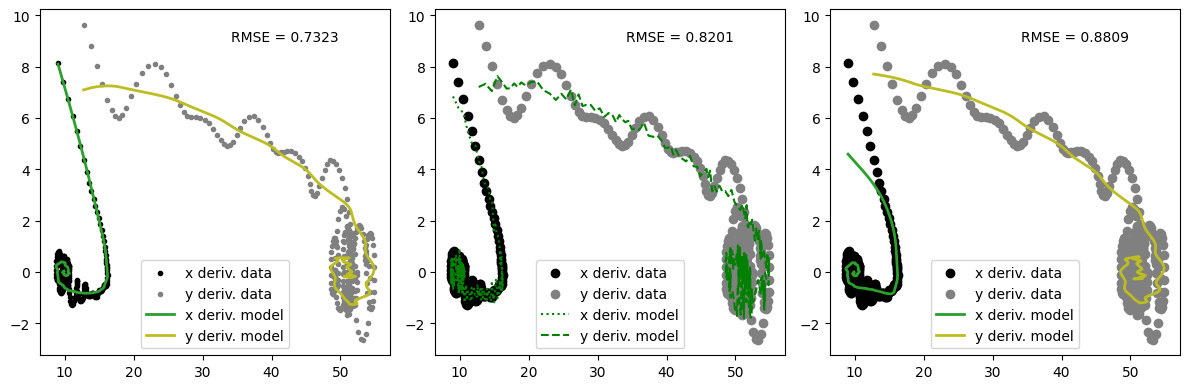

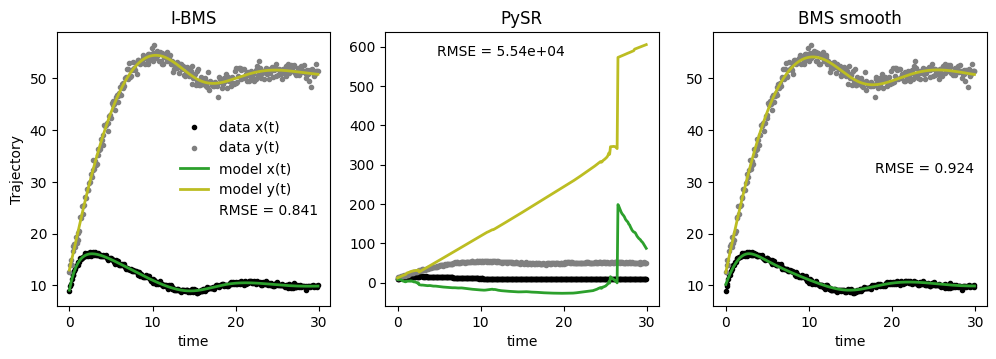

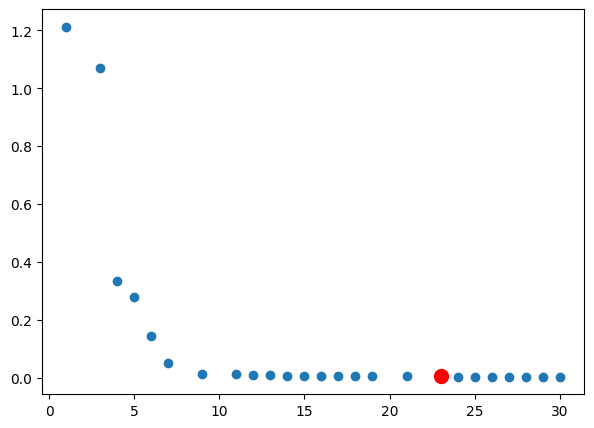

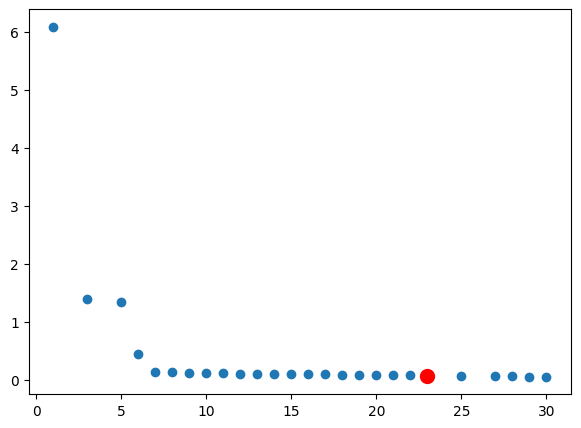

In [2]:
generate_plot('bact_res')

A [Errno 2] No such file or directory: 'models/bar_mag_SNR_20_0_IBMS.pkl'
0
{'x': (_a4_ * (x + _a1_)), 'y': (((_a1_ * cos((y / _a7_))) ** 2) + _a3_)} -507.290967318385
1
{'x': (_a4_ * (_a5_ + x)), 'y': ((cos((y * _a3_)) + _a4_) * _a2_)} -511.809868597519
2
{'x': ((_a5_ * x) + _a7_), 'y': ((_a7_ * x) + ((_a4_ + y) / y))} -504.721727944153
3
{'x': ((x + _a5_) * _a3_), 'y': (((_a5_ + y) * sin(y)) + _a1_)} -512.310656745381
4
{'x': (_a4_ * (x + _a6_)), 'y': ((sin(y) * (y + _a4_)) + _a3_)} -512.310656745372
IBMS best model -512.310656745381 {'x': ((x + _a5_) * _a3_), 'y': (((_a5_ + y) * sin(y)) + _a1_)}
IBMS init values 4.2030046792899265 4.759473160996926
RSME deriv:  0.0029023295820172425
RSME integral:  0.00285450054821759
    complexity      loss                                           equation  \
0            1  0.037438                                        0.116579585   
1            3  0.022062                                     square(sin(y))   
2            4  0.000514        

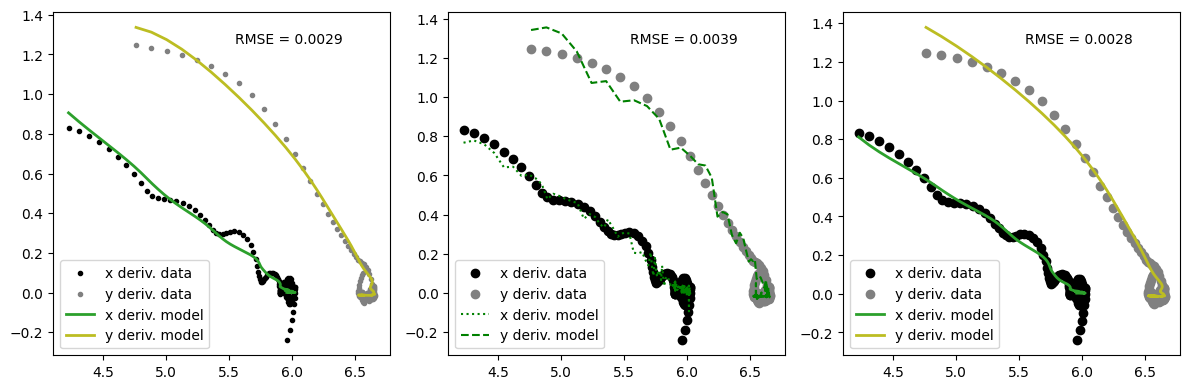

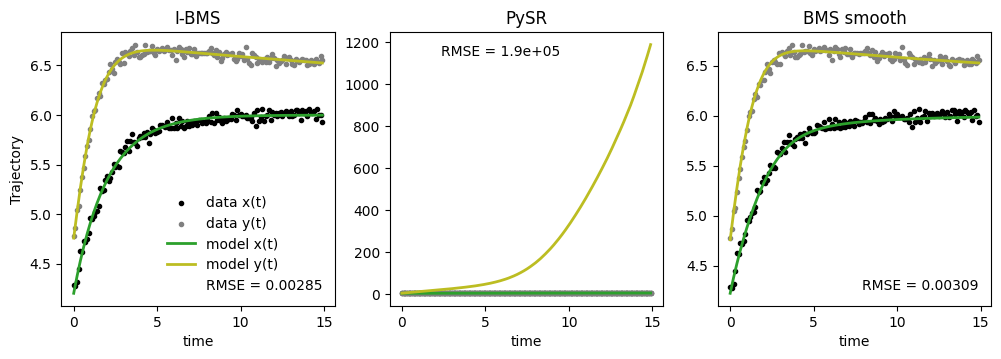

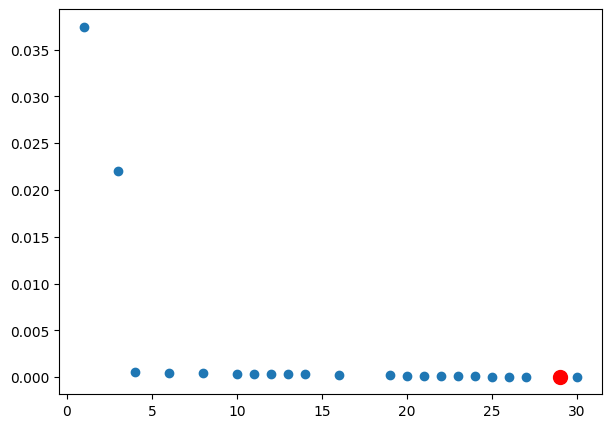

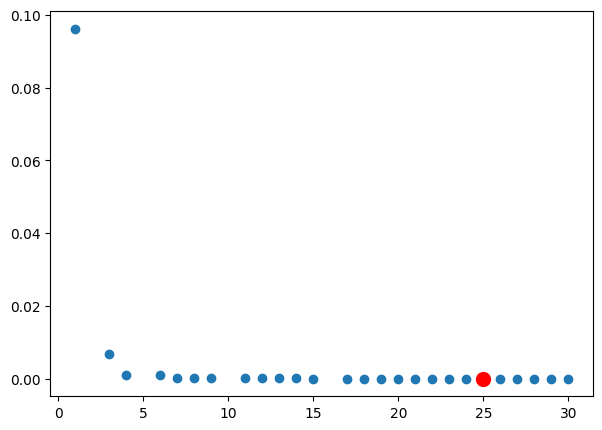

In [3]:
pysr_complexity_x = 6
pysr_complexity_y = 4
generate_plot('bar_mag')

A [Errno 2] No such file or directory: 'models/glider_SNR_20_0_IBMS.pkl'
0
{'x': (-(x) + ((_a5_ * ((sin(y) * _a6_) + (y * sin(x)))) + _a1_)), 'y': exp(((x * _a3_) * (_a7_ ** x)))} 448.891978487118
1
{'x': ((((_a3_ ** cos((y ** _a7_))) + (y / (-((y + (_a2_ + _a7_))) * _a4_))) * (_a0_ + y)) * y), 'y': (((_a1_ + (_a0_ / (_a1_ + exp(x)))) ** 2) / x)} 405.671271186224
2
{'x': (_a3_ * (sin(y) + (x * _a5_))), 'y': (((_a6_ ** x) * ((-((x + (_a7_ / _a7_))) / _a2_) + (_a7_ / y))) + _a0_)} 392.032629338395
3
{'x': ((_a6_ + (_a0_ * (((y * sin((y * _a2_))) ** 2) * sin(y)))) * x), 'y': ((_a6_ / (y ** 3)) + ((x * _a7_) + _a5_))} 426.735897350274
4
{'x': (((_a5_ * (_a0_ ** (x + sin(y)))) * y) + (_a3_ / _a0_)), 'y': y} 462.837869302736
IBMS best model 392.032629338395 {'x': (_a3_ * (sin(y) + (x * _a5_))), 'y': (((_a6_ ** x) * ((-((x + (_a7_ / _a7_))) / _a2_) + (_a7_ / y))) + _a0_)}
IBMS init values 5.1321834883444755 2.1253075108076276
RSME deriv:  4.35639450395593
RSME integral:  6.362611817950453
   

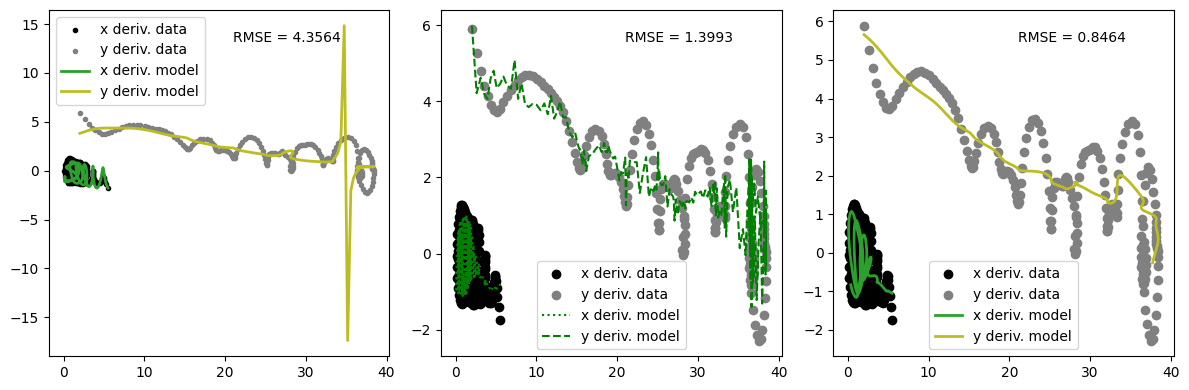

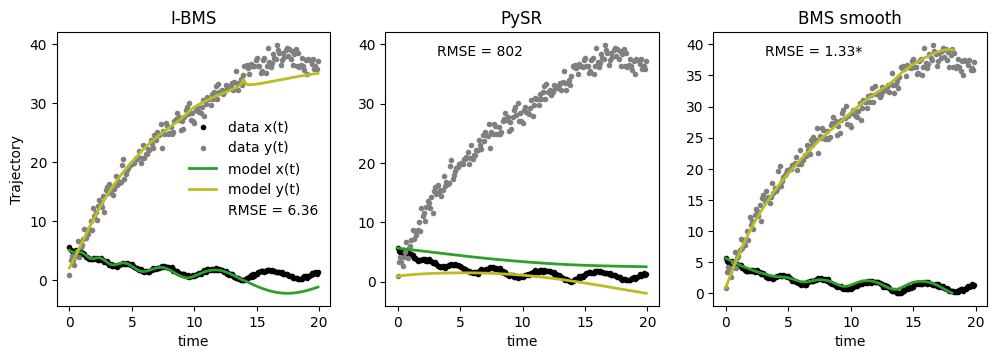

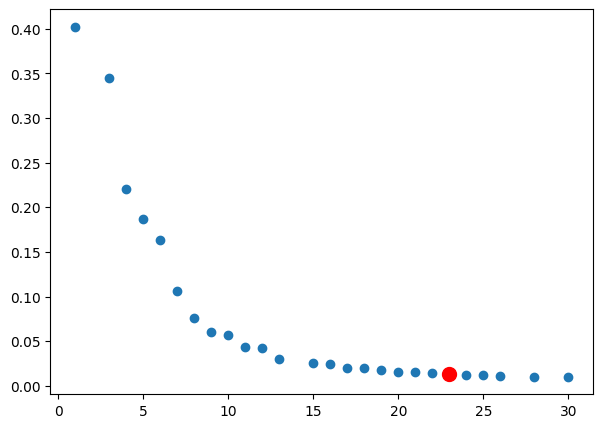

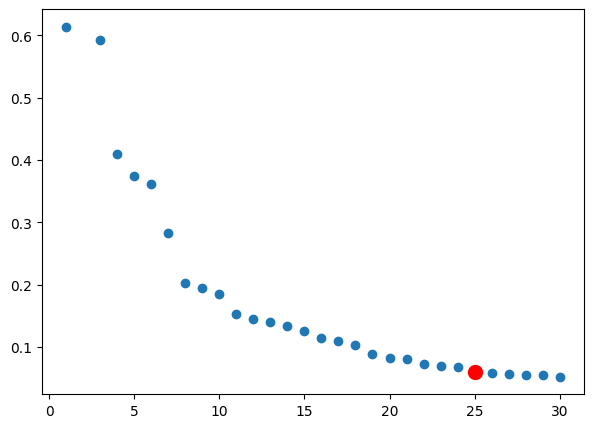

In [4]:
pysr_complexity_x = 10
pysr_complexity_y = 7
generate_plot('glider')

A [Errno 2] No such file or directory: 'models/lotka_volterra_SNR_20_0_IBMS.pkl'
0
{'x': ((x * cos(y)) * _a3_), 'y': ((y + (_a5_ + x)) * (_a2_ * x))} -502.660100409123
1
{'x': (((_a5_ / y) + _a3_) * x), 'y': ((_a5_ + (x + y)) * -(x))} -505.750124721110
2
{'x': ((cos(y) * _a2_) * x), 'y': (-(((x + y) + _a1_)) * x)} -505.840227585094
3
{'x': ((_a5_ * x) * cos(y)), 'y': (-((y + (x + _a5_))) * x)} -505.840227585245
4
{'x': ((_a2_ * (y + _a3_)) * x), 'y': -((x * (y + (_a2_ + x))))} -504.420948369319
IBMS best model -505.840227585245 {'x': ((_a5_ * x) * cos(y)), 'y': (-((y + (x + _a5_))) * x)}
IBMS init values 1.0059978353676753 3.0144123949532986
RSME deriv:  0.12767318461527105
RSME integral:  0.0004907662846675991
    complexity      loss                                           equation  \
0            1  0.042060                                        -0.07571265   
1            3  0.002349                                    x / -0.77482045   
2            4  0.002156                  

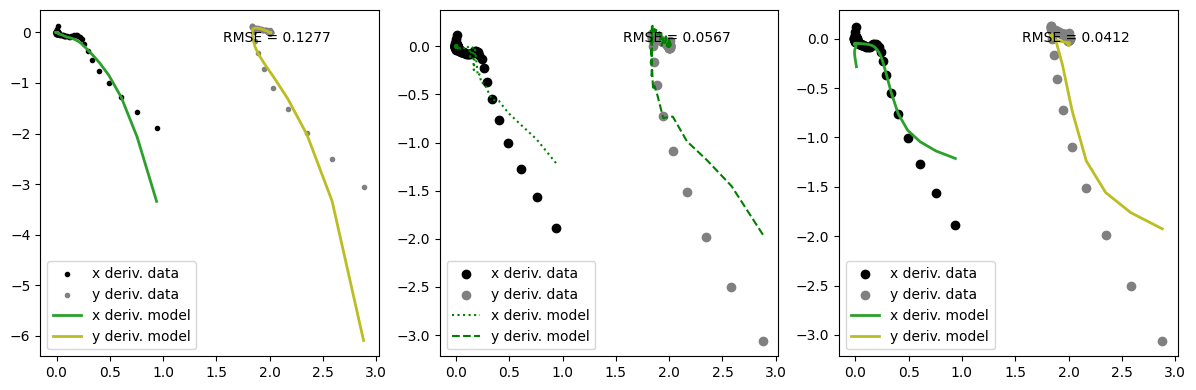

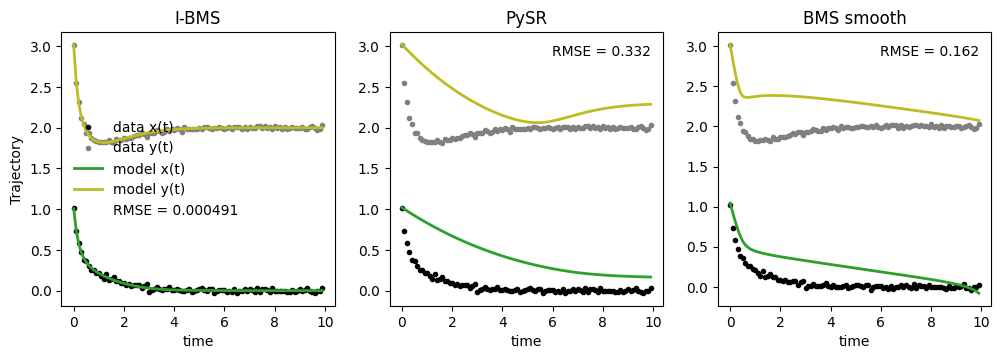

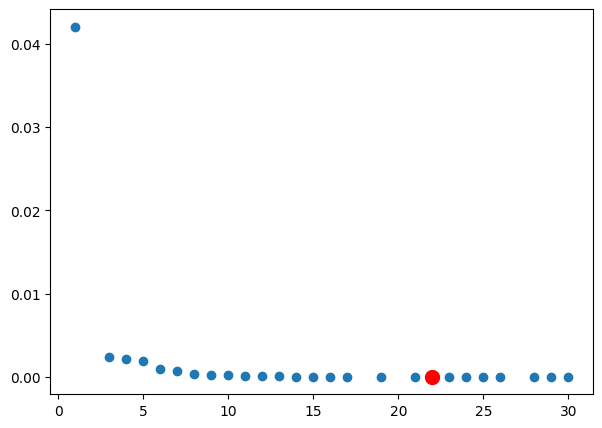

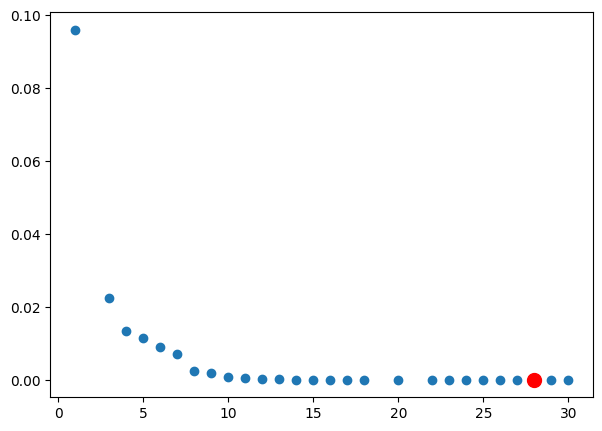

In [5]:
pysr_complexity_x = 6
pysr_complexity_y = 8
generate_plot('lotka_volterra')

A [Errno 2] No such file or directory: 'models/pred_prey_SNR_20_0_IBMS.pkl'
0
{'x': (-(((_a6_ * x) + _a3_)) + ((_a1_ + (_a7_ * x)) * (-(y) * _a1_))), 'y': ((((((y + (y * (_a1_ * (y ** 2)))) + (_a7_ * (x ** 2))) + _a5_) ** 3) + _a0_) + sin(y))} 57.5384629554273
1
{'x': ((_a7_ + ((_a0_ * x) + y)) * _a4_), 'y': (((_a0_ * (x ** _a7_)) + (y * _a2_)) * x)} 135.628696847641
2
{'x': (((_a3_ + (_a0_ * x)) * -(((_a0_ + y) + _a7_))) + _a5_), 'y': (((((x * _a0_) + ((((y ** 2) * ((_a5_ + y) / (_a1_ * _a1_))) + _a2_) + y)) * (x + x)) + _a7_) / _a3_)} 83.0927343622426
3
{'x': (((y + ((y * x) + _a1_)) / _a6_) + (sin(x) * (_a5_ * x))), 'y': ((y + (_a0_ * x)) * (x / _a5_))} 64.5741159637392
4
{'x': ((((_a0_ * (_a7_ ** x)) + y) * (_a1_ * _a6_)) + (x * (-(_a5_) * (x + (_a0_ + (_a1_ * y)))))), 'y': (((((_a3_ ** y) * y) * _a6_) + (_a5_ * (_a6_ + x))) * x)} 30.3707296514015
IBMS best model 30.3707296514015 {'x': ((((_a0_ * (_a7_ ** x)) + y) * (_a1_ * _a6_)) + (x * (-(_a5_) * (x + (_a0_ + (_a1_ * y)))))), 'y'

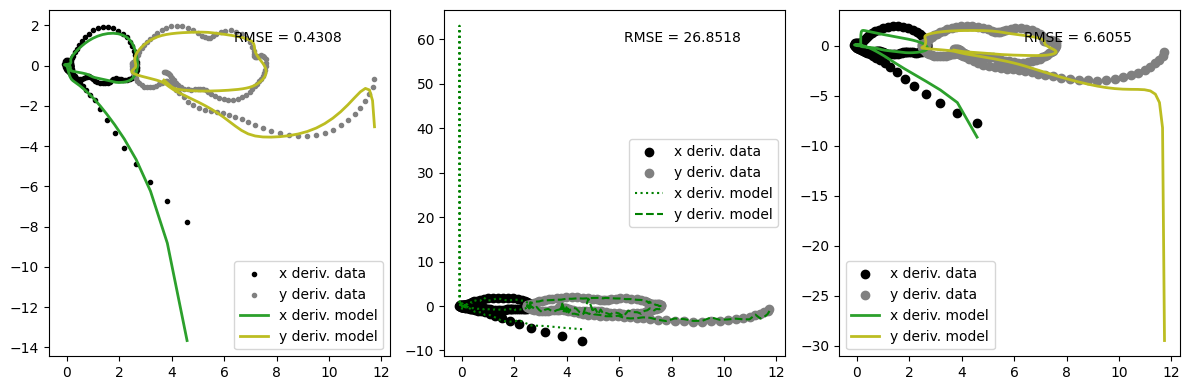

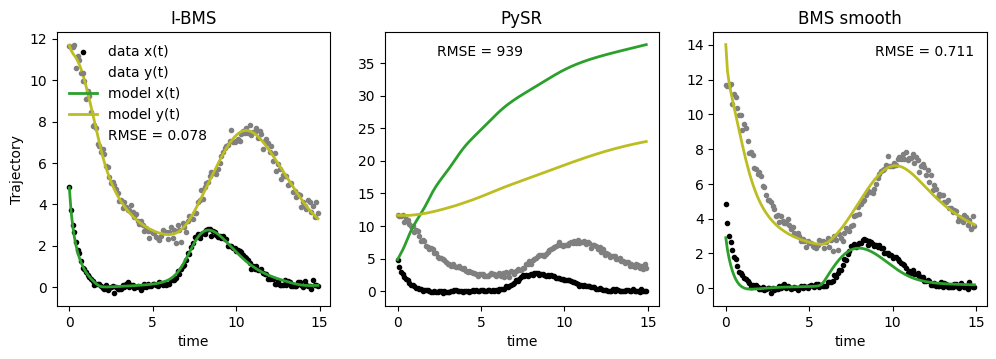

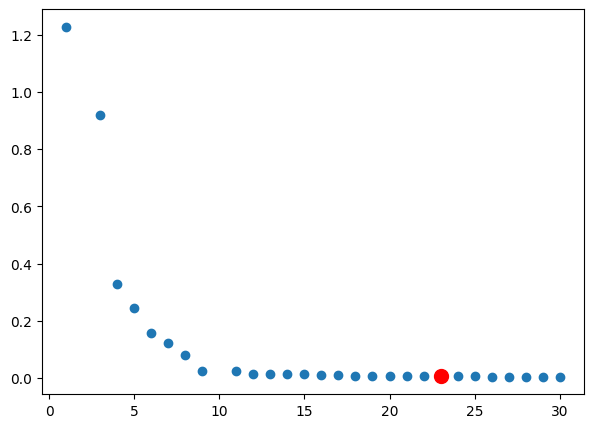

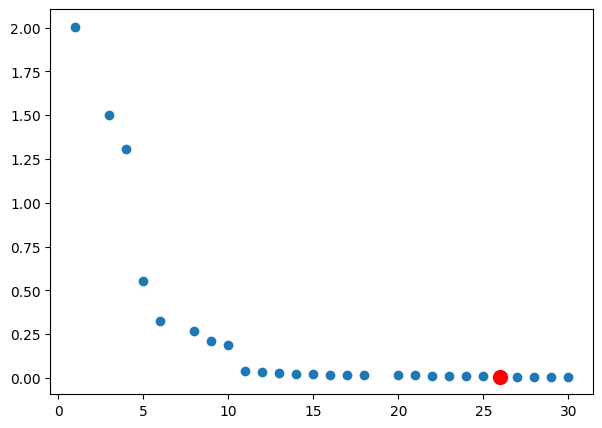

In [6]:
pysr_complexity_x = 9
pysr_complexity_y = 11
generate_plot('pred_prey')

A [Errno 2] No such file or directory: 'models/sh_flow_SNR_20_0_IBMS.pkl'
0
{'x': ((_a5_ * (y + _a1_)) ** 3), 'y': ((y * (sin(x) + _a1_)) * _a4_)} -386.166691199061
1
{'x': ((y + _a0_) * (_a2_ * cos((x * _a6_)))), 'y': ((sin(x) + _a4_) * (_a1_ * y))} -379.118966468037
2
{'x': ((_a2_ * cos(y)) ** 3), 'y': (_a6_ / (((y ** 3) ** 3) + (_a1_ / y)))} -363.047536701908
3
{'x': ((_a4_ * (y + _a3_)) ** 3), 'y': ((sin(((y ** 2) * _a7_)) / y) * _a0_)} -379.675747212707
4
{'x': ((_a5_ * (y + _a0_)) ** 3), 'y': (((_a7_ ** 2) * sin((y / _a3_))) * _a3_)} -368.701229673850
IBMS best model -386.166691199061 {'x': ((_a5_ * (y + _a1_)) ** 3), 'y': ((y * (sin(x) + _a1_)) * _a4_)}
IBMS init values -1.3500184114020997 -1.444675564734108
RSME deriv:  0.01608725292494284
RSME integral:  0.017539902615215545
    complexity      loss                                           equation  \
0            1  0.259472                                      0.00017647813   
1            3  0.039170                       

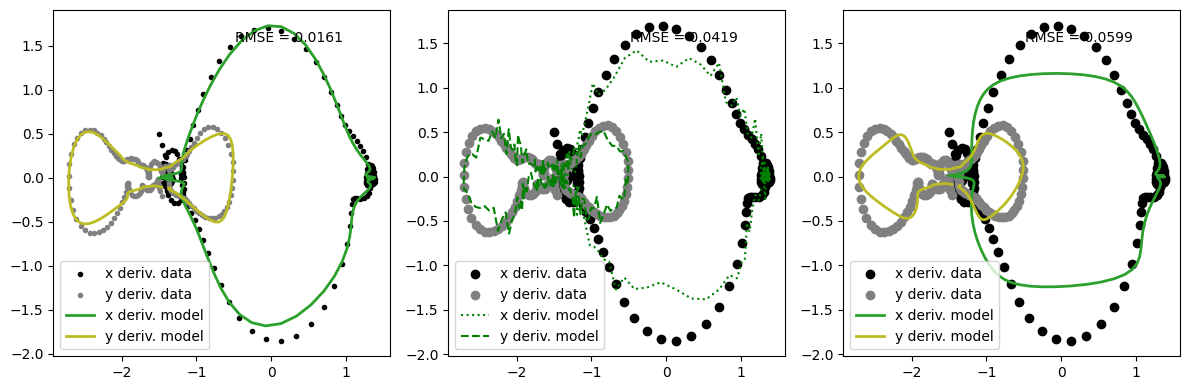

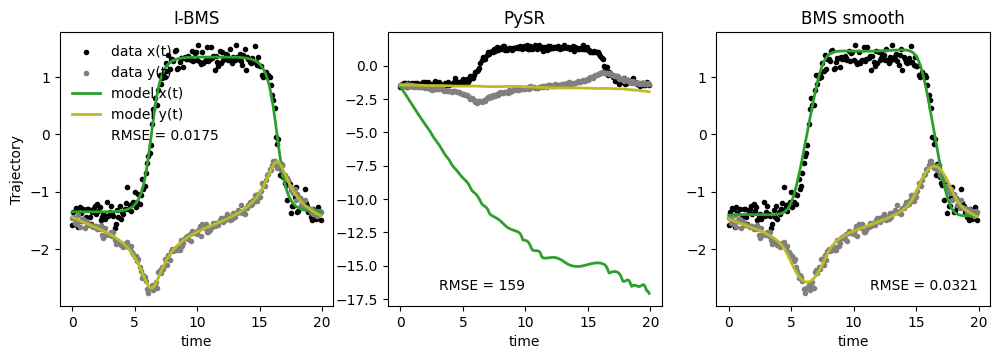

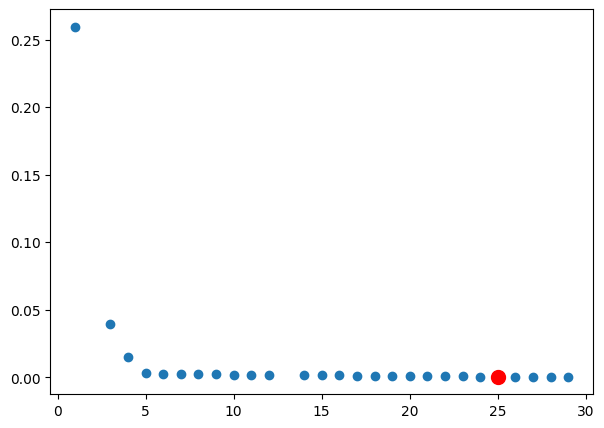

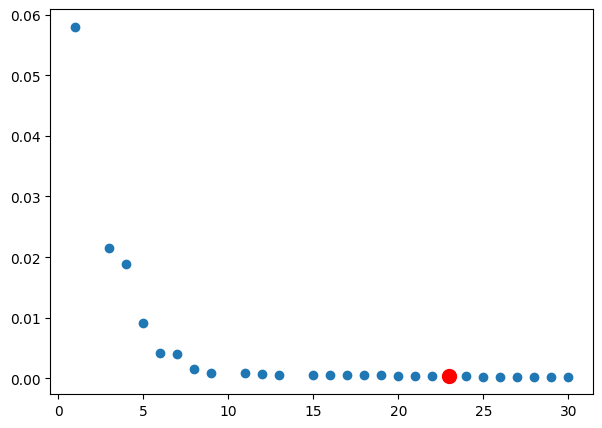

In [7]:
pysr_complexity_x = 5
pysr_complexity_y = 10
generate_plot('sh_flow')

A [Errno 2] No such file or directory: 'models/vd_pol_SNR_20_0_IBMS.pkl'
0
{'x': (sin((((_a7_ / _a6_) + (x ** _a1_)) * x)) + (y * _a5_)), 'y': (_a6_ / (_a0_ / y))} -508.555465456523
1
{'x': ((y * _a5_) ** 3), 'y': (_a2_ * sin(y))} -407.094785018707
2
{'x': (sin((x * (_a0_ + ((x / x) * _a0_)))) + (((y * _a1_) + (y ** 3)) / _a2_)), 'y': (_a4_ * sin(y))} -493.800745509499
3
{'x': ((_a0_ * y) + ((x * _a6_) + ((_a2_ * x) ** 3))), 'y': (y * _a3_)} -546.747491132703
4
{'x': ((((_a2_ * x) + (y + (sin((_a0_ * x)) * _a1_))) * _a2_) / _a3_), 'y': (_a5_ * y)} -530.962708269845
IBMS best model -546.747491132703 {'x': ((_a0_ * y) + ((x * _a6_) + ((_a2_ * x) ** 3))), 'y': (y * _a3_)}
IBMS init values 0.38923721655110105 0.21468737699757276
RSME deriv:  0.10238372822003537
RSME integral:  0.007920044648542509
    complexity      loss                                           equation  \
0            1  0.354952                                                  y   
1            3  0.090342             

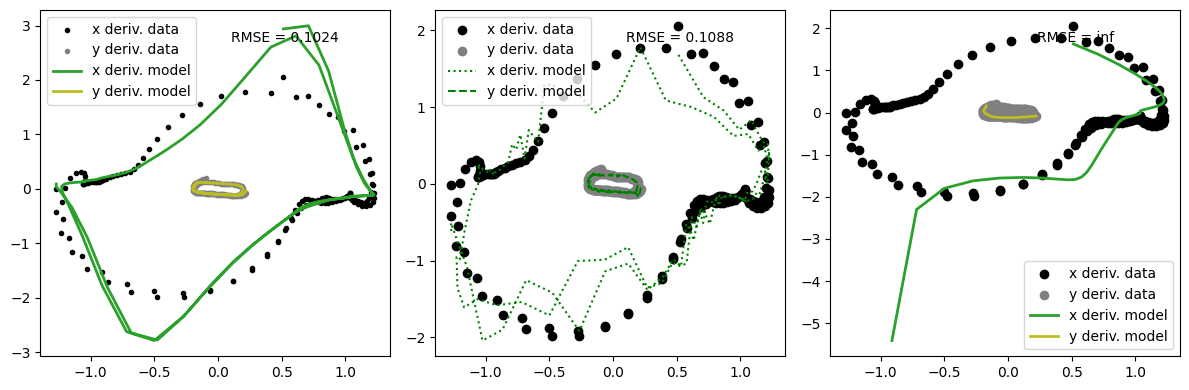

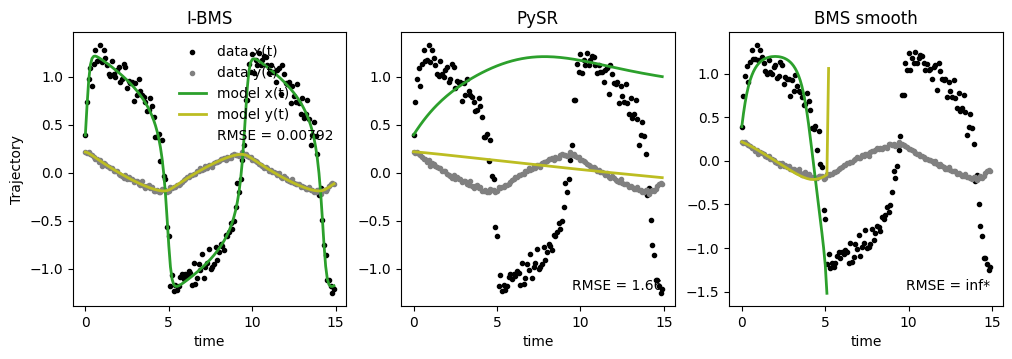

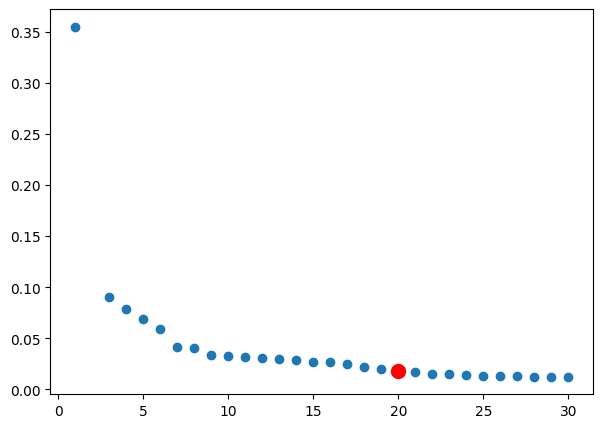

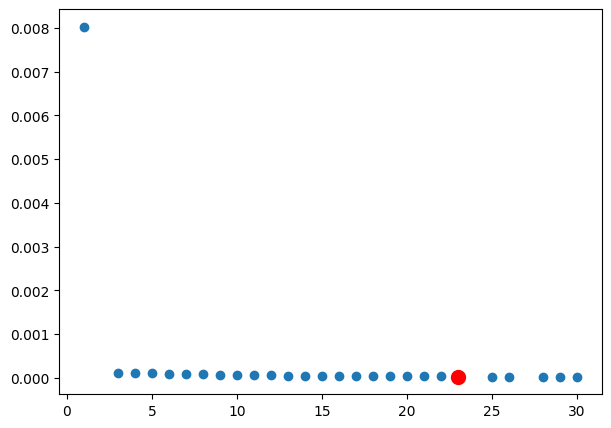

In [8]:
pysr_complexity_x = 7
pysr_complexity_y = 3
generate_plot('vd_pol')

In [10]:
import pandas as pd

# ----------------------------------------------------------
# Build dataframe from accumulated results
# ----------------------------------------------------------

df = pd.DataFrame({
    k: pd.Series(v)
    for k, v in export_data.items()
})

# Build the equation row
eq_row = {}

for col in df.columns:

    # Time and data columns have no equation
    if col.endswith("_time"):
        eq_row[col] = "Time"
    elif "_data_" in col:
        eq_row[col] = "Measured data"

    # BMS / PySR equations
    else:
        eq_row[col] = export_equations.get(col, "")

# Insert equation row as first row
df = pd.concat(
    [pd.DataFrame([eq_row]), df],
    ignore_index=True,
)

# Save
filename = "integrated_models.csv"
df.to_csv(filename, index=False)

print(f"Saved {filename}")
display(df.head())

Saved integrated_models.csv


,bact_res_data_time,bact_res_data_x,bact_res_data_y,bact_res_IBMS_time,bact_res_IBMS_x,bact_res_IBMS_y,bact_res_PySR_time,bact_res_PySR_x,bact_res_PySR_y,bact_res_BMS_time,...,vd_pol_data_y,vd_pol_IBMS_time,vd_pol_IBMS_x,vd_pol_IBMS_y,vd_pol_PySR_time,vd_pol_PySR_x,vd_pol_PySR_y,vd_pol_BMS_time,vd_pol_BMS_x,vd_pol_BMS_y
0,Time,Measured data,Measured data,Time,$c_{1} x + c_{2} + \frac{c_{3} \left(c_{4} + y...,$c_{1} + \frac{c_{2} y}{x}$,Time,$\left(a_{2} + a_{4} x\right) \cos{\left(\frac...,$a_{2} + \frac{a_{4} y + \left(- \sin{\left(a_...,Time,...,Measured data,Time,$\frac{c_{1} \left(c_{1} x + c_{2} \sin{\left(...,$c_{1} x$,Time,$a_{2} x \cos{\left(\frac{a_{3}}{a_{1} - y} \r...,$x \left(a_{0} - \left(a_{1} - x \left(a_{2} y...,Time,$c_{1} c_{2}^{3 x^{3}} y^{3} + y$,$c_{1} \left(c_{2} c_{3} x + e^{c_{3} y}\right)$
1,0.0,8.900336,12.592605,0.0,9.070486,12.954587,0.0,8.900336,12.592605,0.0,...,0.217241,0.0,0.389237,0.214687,0.0,0.392692,0.217241,0.0,0.392692,0.217241
2,0.1,9.961501,13.945913,0.1,9.842557,13.667616,0.1,8.627161,13.54087,0.1,...,0.20085,0.1,0.692949,0.209404,0.1,0.419546,0.215885,0.1,0.543118,0.208639
3,0.2,10.316743,14.851673,0.2,10.543591,14.386742,0.2,8.259452,14.443356,0.2,...,0.210993,0.2,0.95708,0.201272,0.2,0.445672,0.214478,0.2,0.669158,0.199933
4,0.3,11.332606,14.016812,0.3,11.179314,15.10941,0.3,7.784339,15.298826,0.3,...,0.189988,0.3,1.117585,0.191041,0.3,0.471061,0.213019,0.3,0.772639,0.190941
